In [1]:
# Remove all CSV files in the current notebook directory (non-recursive)

from pathlib import Path

DELETE = True  # <- set to True to actually delete

here = Path.cwd()
csv_files = sorted([p for p in here.glob("*.csv") if p.is_file()])

print(f"Notebook directory: {here}")
print(f"Found {len(csv_files)} CSV file(s):")
for p in csv_files:
    print(" -", p.name)

if not csv_files:
    print("Nothing to delete.")
elif DELETE:
    for p in csv_files:
        try:
            p.unlink()
            print(f"Deleted: {p.name}")
        except Exception as e:
            print(f"Failed to delete {p.name}: {e}")
    print("Done.")
else:
    print("\nDry run only. Set DELETE=True to remove these files.")


Notebook directory: c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases
Found 48 CSV file(s):
 - coarse_hyperboloid_COEFFS.csv
 - coarse_hyperboloid_COEFFS_Transformed.csv
 - coarse_hyperboloid_COEFFS_Transformed_Volume.csv
 - coarse_hyperboloid_POINT_TYPES.csv
 - coarse_hyperboloid_RINGS.csv
 - coarse_hyperboloid_transf_COEFFS.csv
 - coarse_hyperboloid_transf_COEFFS_Transformed.csv
 - coarse_hyperboloid_transf_COEFFS_Transformed_Volume.csv
 - coarse_hyperboloid_transf_POINT_TYPES.csv
 - coarse_hyperboloid_transf_RINGS.csv
 - coarse_hyperboloid_transf_Tri_TYPE.csv
 - coarse_hyperboloid_Tri_TYPE.csv
 - cylinder_COEFFS.csv
 - cylinder_COEFFS_Transformed.csv
 - cylinder_COEFFS_Transformed_Volume.csv
 - cylinder_POINT_TYPES.csv
 - cylinder_RINGS.csv
 - cylinder_Tri_TYPE.csv
 - Ellip_0_sub0_full_COEFFS.csv
 - Ellip_0_sub0_full_COEFFS_Transformed.csv
 - Ellip_0_sub0_full_COEFFS_Transformed_Volume.csv
 - Ellip_0_sub0_full_POINT_TYPES.csv
 - Ellip_0_sub0_full_RINGS.

## 1. Circular Cylinder
### 1.1 Load Cylinder Mesh & Fit Local Quadrics (ABC Coefficients)

In [2]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

bench = QuadricCoeffsFromMsh("cylinder.msh", method={})
bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(), bench.coeffs_meta



[triangles] faces: 374
[mesh] points=229  surface_triangles=374
[RIM CHECK] theta_max_deg=35.0  dihedral(115)=0.000000  rim_flags[115]=False
[smooth] components: 3 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\cylinder_POINT_TYPES.csv  (rim=42, planar=38, curved=109, surface_points=189, total_points=229)

[DEBUG T208] verts: A=14 B=136 C=116  rim-depths=(1000000000, 1000000000, 1000000000)
[DEBUG T208] |A|=12  |B|=17  |C|=15  |ABC|=12
[DEBUG T208] ABC IDs: [12, 13, 14, 15, 16, 17, 111, 114, 116, 136, 139, 140]
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\cylinder_COEFFS.csv  (rows kept=180, skipped_flat=194, total_tris=374)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\cylinder_Tri_TYPE.csv  (triangles=374)
[write] rings -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\d

(   triangle_id  component_id  component_size  A_id        Ax            Ay  \
 0            0             0             180     0  1.000000 -2.449294e-16   
 1            1             0             180    21  0.955573 -2.947552e-01   
 2            2             0             180    24  1.000000 -2.449294e-16   
 3            3             0             180     0  1.000000 -2.449294e-16   
 4            4             0             180     1  1.000000 -2.449294e-16   
 
      Az  B_id        Bx        By  ...  C_A  C_B  C_C  C_D  C_E  C_F  C_G  \
 0  0.50   106  0.982109  0.188311  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0   
 1  0.50   110  0.982279 -0.187425  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0   
 2  0.25   106  0.982109  0.188311  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0   
 3  0.50   110  0.982279 -0.187425  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0   
 4 -0.50   108  0.981943  0.189174  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0   
 
    C_H  C_I  C_J  
 0  0.0  0.0 -1.0  
 1  0.0  0.0 -

### 1.2 Display Circular Cylinder Mesh


Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\cylinder.msh

[loaded] cylinder.msh
  points: 229
  cells[vertex]: 2
  cells[line]: 46
  cells[triangle]: 374
  cells[tetra]: 736
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


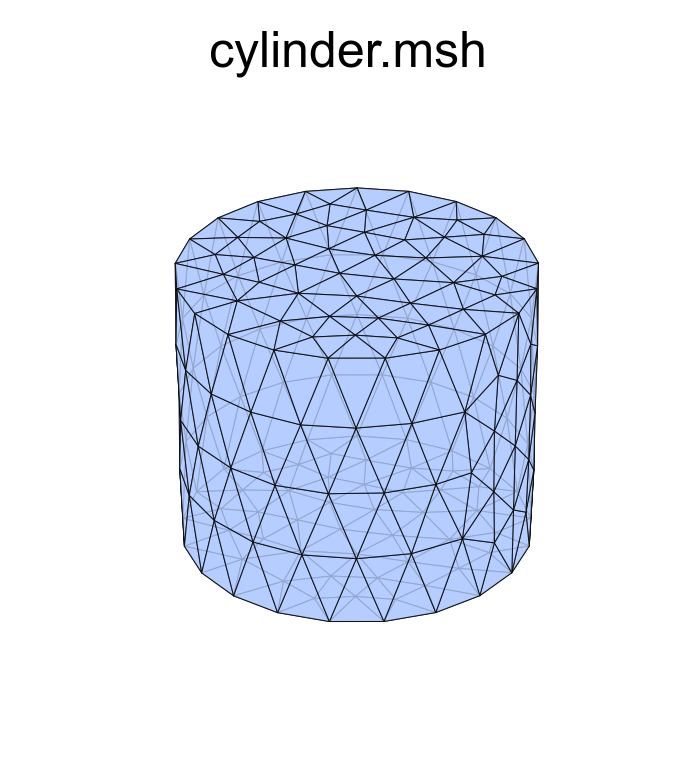

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from benchmarks._plot_mesh import show_mesh

STYLE = Path("./neatplot-main/standard.mplstyle")
plt.style.use(STYLE)

mesh = Path(getattr(bench, "msh_path", "coarse_hyperboloid.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)


### 1.3 Canonicalize & Transform  

In [4]:
# Part-2: transform to canonical space and write <mesh>_COEFFS_Transformed.csv
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta


!!!!debug:input coeffs (raw): (0.9999999999999808, 0.99999999999999, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = 0.9999999999999808 0.99999999999999 0.0 0.0 0.0 0.0 0.0 0.0 0.0 -1.0
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (0.9999999999999808, 0.99999999999999, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (0.9999999999999808, 0.99999999999999, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(-1.0))
!!!!debug:before scaling (unscaled coeffs): (0.9999999999999808, 0.99999999999999, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
a1 0.9999999999999808 b1 0.99999999999999 c1 0.0 d1 0.0 e1 0.0 f1 0.0  g1 0.0 h1 0.0 i1 0.0 j1 -1.0
sx 1.0000000000000095 a1 0.9999999999999808 g1 0.0 j1 -1.0 sy 1.0000000000000049 sz 1.0
A2 0.9999999999999999 B2 0.9999999999999998 C2 0.0 D2 0.0 E2 0.0 F2 0.0  G2 0.0 H2 0.0 I2 0.0 J2 -1.0
A3 0.999999

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0            0     0   106     2               1.0                 1   
 1            1    21   110     0               1.0                 1   
 2            2    24   106     0               1.0                 1   
 3            3     0   110    24               1.0                 1   
 4            4     1   108    22               1.0                 1   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0                 1         1.000000    -2.449294e-16             0.50  ...   
 1                 1         0.955573    -2.947552e-01             0.50  ...   
 2                 1         1.000000    -2.449294e-16             0.25  ...   
 3                 1         1.000000    -2.449294e-16             0.50  ...   
 4                 1         1.000000    -2.449294e-16            -0.50  ...   
 
    ABC_A  ABC_B  ABC_C  ABC_D  ABC_E  ABC_F  ABC_G  ABC_H  ABC_I  ABC_J  
 0 

### 1.4 Curved Volume Estimation, Vertex-Wise Allocation, Aggregation and Error Analysis

In [5]:
import numpy as np
import pandas as pd
import meshio

def tet_volumes(points, tets):
    """
    points: (N,3)
    tets:   (M,4) indices (or (M,k) with k>4; first 4 are the corners)
    returns: (M,) volumes
    """
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    # V = |det([b-a, c-a, d-a])| / 6
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path):
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cell_block in mesh.cells:
        if cell_block.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cell_block.data)))
    return V

# ---- Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

# ---- V_flat from tet mesh (sum of all tetra volumes)
msh_path = "cylinder.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# ---- V_theory = π r^2 h, here r=1, h=1
V_theory = np.pi * 1.0**2 * 1.0  # = π

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_flat=", V_flat)
print("V_sum=", V_sum)

rel = (V_flat + V_sum - V_theory) / V_theory * 100.0
print("**************************************************")
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6e}%")
print("**************************************************")


Saved: trn_Volume.csv
Sum of Vcorrection_scal = 0.033595611731
Sum of Vcorrection = 0.033595611731
Rows: 180, Elapsed: 0.22 s

V_flat= 3.107997169607928
V_sum= 0.033595611731252244
**************************************************
Volume CSV: c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\cylinder_COEFFS_Transformed_Volume.csv
relative error 4.066389e-06%
**************************************************


## 2. Hyperboloid
### 2.1 Load Hyperboloid Mesh & Fit Local Quadrics (ABC Coefficients)

In [6]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

bench = QuadricCoeffsFromMsh("coarse_hyperboloid.msh", method={})
bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(3), bench.coeffs_meta



[triangles] faces: 238
[mesh] points=129  surface_triangles=238
[RIM CHECK] theta_max_deg=35.0  dihedral(115)=0.000000  rim_flags[115]=False
[smooth] components: 3 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_POINT_TYPES.csv  (rim=38, planar=14, curved=69, surface_points=121, total_points=129)

[DEBUG T208] verts: A=32 B=103 C=31  rim-depths=(1000000000, 1000000000, 1000000000)
[DEBUG T208] |A|=11  |B|=14  |C|=11  |ABC|=11
[DEBUG T208] ABC IDs: [1, 19, 29, 30, 31, 32, 99, 101, 103, 115, 116]
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_COEFFS.csv  (rows kept=124, skipped_flat=114, total_tris=238)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_Tri_TYPE.csv  (triangles=238)
[write] rings -> c:\Users\s.deng\Downloads\Reru

(   triangle_id  component_id  component_size  A_id        Ax        Ay  \
 0           57             1             124     0  1.414214  0.000000   
 1           58             1             124    18  1.291948 -0.575212   
 2           59             1             124     4  1.131429  0.000000   
 
          Az  B_id        Bx        By  ...       C_A       C_B       C_C  \
 0 -1.000000     5  1.291948  0.575212  ...  1.000051  1.000000 -1.000000   
 1 -1.000000     0  1.414214  0.000000  ...  1.000051  1.000000 -1.000000   
 2  0.529277    19  1.291948  0.575212  ...  0.999972  0.999963 -0.999968   
 
         C_D       C_E       C_F       C_G       C_H       C_I  C_J  
 0 -0.000006  0.000065  0.000000 -0.000055  0.000000 -0.000069 -1.0  
 1 -0.000006  0.000065  0.000000 -0.000055  0.000000 -0.000069 -1.0  
 2  0.000000 -0.000049  0.000011  0.000026 -0.000009  0.000056 -1.0  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-mast

### 2.2 Display Hyperboloid Mesh

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid.msh

[loaded] coarse_hyperboloid.msh
  points: 129
  cells[triangle]: 57
  cells[triangle]: 124
  cells[triangle]: 57
  cells[tetra]: 355
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


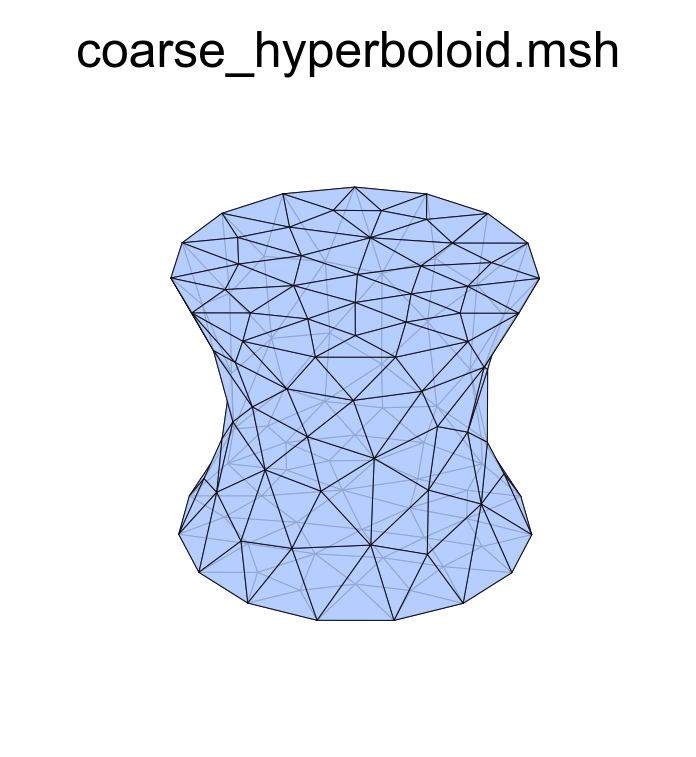

In [7]:


from pathlib import Path
import matplotlib.pyplot as plt
from benchmarks._plot_mesh import show_mesh

STYLE = Path("./neatplot-main/standard.mplstyle")
plt.style.use(STYLE)

mesh = Path(getattr(bench, "msh_path", "coarse_hyperboloid.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)

### 2.3 Canonicalize & Transform

In [8]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (0.9999948431706326, 0.9999771599461844, -0.9999798807461224, 5.622824193001438e-06, 4.390161767379164e-05, 0.0, 0.0, 0.0, -4.901046463604879e-05, -1.0)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = 0.9999948431706326 0.9999771599461844 -0.9999798807461224 5.622824193001438e-06 4.390161767379164e-05 0.0 0.0 0.0 -4.901046463604879e-05 -1.0
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (0.9999948431706326, 0.9999771599461844, -0.9999798807461224, 0.0, 0.0, 0.0, 0.0, 0.0, -4.901046463604879e-05, -1.0)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (0.9999948431706326, 0.9999771599461844, -0.9999798807461224, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(-1.0))
!!!!debug:before scaling (unscaled coeffs): (0.9999948431706326, 0.9999771599461844, -0.9999798807461224, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
a1 0.9999948431706326 b1 0.9999771599461844 c1 -0.9999798807461224 d1 0.0 e1 0.0 f

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0           57     0     5     2          1.000003          1.000011   
 1           58    18     0     2          0.999994          1.000008   
 2           59     4    19     1          1.000003          1.000012   
 3           60    32     4     1          1.000002          1.000012   
 4           61     3    62     2          0.999989          1.000012   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0          1.000010         1.414210         0.000000        -0.999990  ...   
 1          1.000007         1.291956        -0.575208        -0.999965  ...   
 2          1.000010         1.131426         0.000000         0.529243  ...   
 3          1.000010         1.291946        -0.575205         0.999961  ...   
 4          1.000008         1.000011         0.000000         0.000026  ...   
 
       ABC_A     ABC_B     ABC_C     ABC_D     ABC_E     ABC_F     ABC_G  \
 0

### 2.4 Curved Volume Estimation, Vertex-Wise Allocation, Aggregation and Error Analysis

In [9]:
import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    """Return per-tet volumes for a (M,4) (or higher-order) tet connectivity array."""
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

# --- V_flat: total/sum volume of the tet mesh
msh_path = "coarse_hyperboloid.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# --- V_theory = (8/3)π
V_theory = (8.0 / 3.0) * np.pi

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_flat=", V_flat)
print("V_sum =", V_sum)

rel = (V_flat + V_sum - V_theory) / V_theory * 100.0
print("**************************************************")
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6f}%")
print("**************************************************")


[input] C:\Users\S272D~1.DEN\AppData\Local\Temp\tmpf_1f91vx\rot.csv
Triangles kept (curved): 124 | planar skipped: 0
Patch-based total (sum of patches): 0.07659463
Total elapsed: 0.49 s
[write] C:\Users\S272D~1.DEN\AppData\Local\Temp\tmpf_1f91vx\rot_Volume.csv

V_flat= 8.30147791747638
V_sum = 0.07659462969037052
**************************************************
Volume CSV: c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_COEFFS_Transformed_Volume.csv
relative error 0.005874%
**************************************************


## 3. Paraboloid
### 3.1 Load Paraboloid Mesh & Fit Local Quadrics (ABC Coefficients)

In [10]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

#bench = QuadricCoeffsFromMsh("coarse_paraboloid.msh", method={})
bench = QuadricCoeffsFromMsh("snapped_paraboloid_ascii.msh", method={})

bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(3), bench.coeffs_meta



[triangles] faces: 174
[mesh] points=97  surface_triangles=174
[RIM CHECK] vid 115 out of range (nV=97); skipping per-vertex print.
[smooth] components: 2 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_paraboloid_ascii_POINT_TYPES.csv  (rim=18, planar=7, curved=64, surface_points=89, total_points=97)
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_paraboloid_ascii_COEFFS.csv  (rows kept=117, skipped_flat=57, total_tris=174)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_paraboloid_ascii_Tri_TYPE.csv  (triangles=174)
[write] rings -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_paraboloid_ascii_RINGS.csv  (triangles=174)


(   triangle_id  component_id  component_size  A_id        Ax   Ay        Az  \
 0            0             0             117     2  0.455629  0.0  0.207598   
 1            1             0             117     0  0.000000  0.0  0.000000   
 2            2             0             117     0  0.000000  0.0  0.000000   
 
    B_id        Bx        By  ...  C_A  C_B  C_C  C_D  C_E  C_F  C_G  C_H  C_I  \
 0    51  0.177750 -0.411273  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0 -1.0   
 1    53  0.180521  0.418341  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0 -1.0   
 2    52 -0.245238 -0.413616  ...  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0 -1.0   
 
             C_J  
 0  1.588233e-16  
 1  9.784899e-17  
 2  9.767026e-17  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-master_BenchmarkCases\\snapped_paraboloid_ascii_COEFFS.csv',
  'total_tris': 174,
  'skipped_flat': 57})

### 3.2 Paraboloid Mesh Display

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_paraboloid_ascii.msh

[loaded] snapped_paraboloid_ascii.msh
  points: 97
  cells[triangle]: 117
  cells[triangle]: 57
  cells[tetra]: 264
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


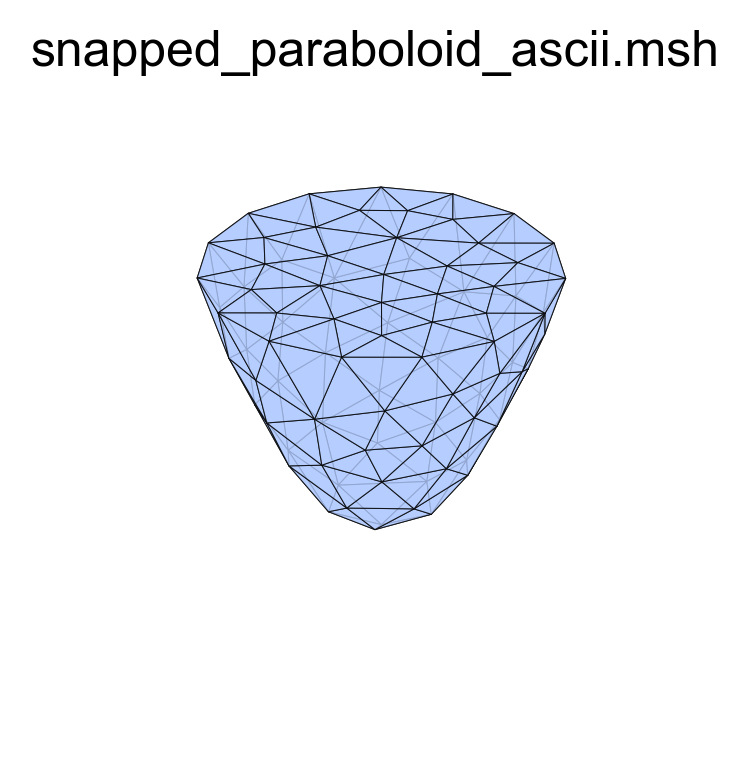

In [11]:
from pathlib import Path
from benchmarks._plot_mesh import show_mesh
#%pip install "jupyterlab>=3" ipywidgets "pyvista[all,trame]"
mesh = Path(getattr(bench, "msh_path", "snapped_paraboloid_ascii.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)



### 3.3 Canonicalize & Transform

In [12]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.9999999999999992, -3.026034937881642e-16)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = 1.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 -0.9999999999999992 -3.026034937881642e-16
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.9999999999999992, -3.026034937881642e-16)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.9999999999999992, np.float64(0.0))
!!!!debug:before scaling (unscaled coeffs): (1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.9999999999999992, 0.0)
a1 1.0 b1 1.0 c1 0.0 d1 0.0 e1 0.0 f1 0.0  g1 0.0 h1 0.0 i1 -0.9999999999999992 j1 0.0
sx 1.0 a1 1.0 g1 0.0 j1 0.0 sy 1.0 sz 1.0000000000000009
A2 1.0 B2 1.0 C2 0.0 D2 0.0 E2 0.0 F2 0.0  G2 0.0 H2 0.0 I2 -1.0 J2 0.0
A3 1.0 B3 1.0 C3 0.0 D3 0.0 E3 0.0 F3 0.0  G3 0.0 H3 0.0 I3 -1.0 J3 0.0
!!!!debug:scale_facto

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0            0     2    51     0                 1                 1   
 1            1     0    53     2                 1                 1   
 2            2     0    52    20                 1                 1   
 3            3    20    53     0                 1                 1   
 4            4    51    52     0                 1                 1   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0                 1         0.455629         0.000000         0.207598  ...   
 1                 1         0.000000         0.000000         0.000000  ...   
 2                 1         0.000000         0.000000         0.000000  ...   
 3                 1        -0.427680         0.048233         0.185237  ...   
 4                 1         0.177750        -0.411273         0.200741  ...   
 
    ABC_A  ABC_B  ABC_C  ABC_D  ABC_E  ABC_F  ABC_G  ABC_H  ABC_I         ABC_

### 3.4 Curved Volume Estimation, Vertex-Wise Allocation, Aggregation and Error Analysis

In [13]:
import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

import numpy as np, pandas as pd
# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

# --- V_flat: total/sum volume of the tet mesh
msh_path = "snapped_paraboloid_ascii.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# --- V_theory = 2π
V_theory = 2.0 * np.pi

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_flat=", V_flat)
print("V_sum =", V_sum)

rel = (V_flat + V_sum - V_theory) / V_theory * 100.0
print("**************************************************")
print("V_sum=", V_sum)
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6f}%")
print("**************************************************")


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\ddgclib\../benchmarks\_3_4_shared_axisymmetric_utils.py:1106: RuntimeWarning: divide by zero encountered in divide
  s = 1.0 / np.sqrt(denom)
c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\ddgclib\../benchmarks\_3_4_shared_axisymmetric_utils.py:1108: RuntimeWarning: invalid value encountered in multiply
  pts_surf = pts_plane * s[:, None]  # shape (M, 3)


[input] C:\Users\S272D~1.DEN\AppData\Local\Temp\tmphd7goyfj\rot.csv
Triangles kept (curved): 117 | planar skipped: 0
Patch-based total (sum of patches): 0.27958403
Total elapsed: 0.16 s
[write] C:\Users\S272D~1.DEN\AppData\Local\Temp\tmphd7goyfj\rot_Volume.csv

V_flat= 6.003365135645098
V_sum = 0.2795840300049701
**************************************************
V_sum= 0.2795840300049701
Volume CSV: c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_paraboloid_ascii_COEFFS_Transformed_Volume.csv
relative error -0.003758%
**************************************************


## 4. Parabolic Cylinder
### 4.1 Load Parabolic Cylinder Mesh & Fit Local Quadrics (ABC Coefficients)

In [14]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

bench = QuadricCoeffsFromMsh("parabolic_cylinder_y_eq_x2_y1slice.msh", method={})
bench = QuadricCoeffsFromMsh("snapped_y_eq_x2_ascii.msh", method={})

bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(3), bench.coeffs_meta


[triangles] faces: 266
[mesh] points=135  surface_triangles=266
[RIM CHECK] theta_max_deg=35.0  dihedral(115)=32.078214  rim_flags[115]=False
[smooth] components: 5 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_POINT_TYPES.csv  (rim=34, planar=6, curved=88, surface_points=128, total_points=135)

[DEBUG T208] verts: A=39 B=115 C=40  rim-depths=(1000000000, 1000000000, 1000000000)
[DEBUG T208] |A|=13  |B|=18  |C|=13  |ABC|=20
[DEBUG T208] ABC IDs: [4, 6, 38, 39, 40, 41, 104, 105, 106, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 121]
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_COEFFS.csv  (rows kept=104, skipped_flat=162, total_tris=266)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_Tri_TYPE.csv  (triangle

(   triangle_id  component_id  component_size  A_id        Ax        Ay   Az  \
 0           52             1             104     0 -1.414214  2.000000 -1.0   
 1           53             1             104    22 -1.222177  1.493717 -1.0   
 2           54             1             104    10 -1.414214  2.000000  0.5   
 
    B_id        Bx        By  ...  C_A  C_B  C_C  C_D  C_E  C_F  C_G  C_H  C_I  \
 0    70 -1.292450  1.670427  ... -1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   
 1    70 -1.292450  1.670427  ... -1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   
 2    66 -1.288155  1.659344  ... -1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   
 
             C_J  
 0 -3.176313e-11  
 1  2.374094e-14  
 2 -5.011604e-14  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-master_BenchmarkCases\\snapped_y_eq_x2_ascii_COEFFS.csv',
  'total_tris': 266,
  'skipped_flat': 162})

### 4.2 Parabolic Cylinder Mesh Display

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii.msh

[loaded] snapped_y_eq_x2_ascii.msh
  points: 135
  cells[triangle]: 52
  cells[triangle]: 26
  cells[triangle]: 26
  cells[triangle]: 21
  cells[triangle]: 21
  cells[triangle]: 42
  cells[triangle]: 52
  cells[triangle]: 13
  cells[triangle]: 13
  cells[tetra]: 271
  cells[tetra]: 149
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


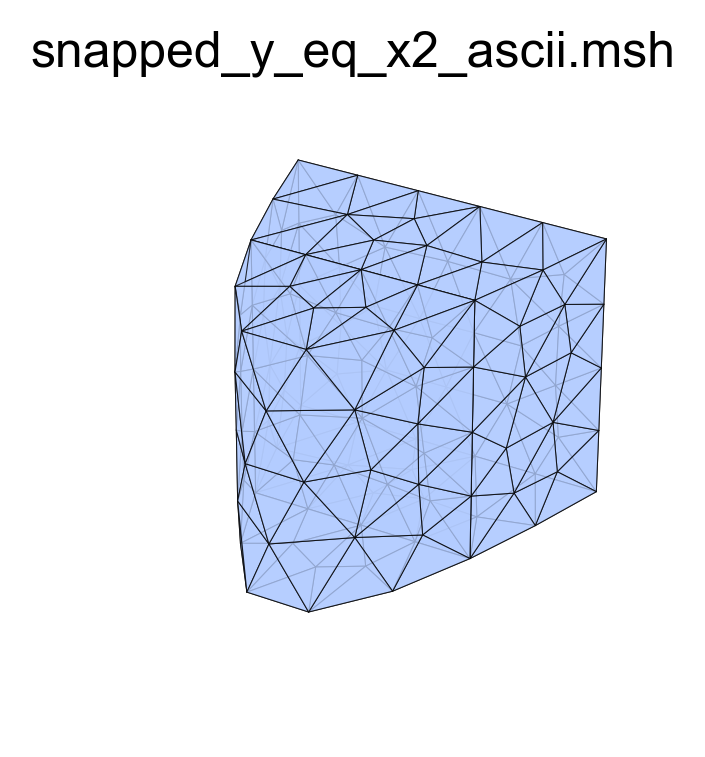

In [15]:
from pathlib import Path
from benchmarks._plot_mesh import show_mesh

mesh = Path(getattr(bench, "msh_path", "coarse_hyperboloid.msh")).resolve()
mesh = Path(getattr(bench, "msh_path", "snapped_y_eq_x2_ascii.msh")).resolve()

print("Plotting mesh:", mesh)
show_mesh(mesh)


### 4.3 Canonicalize & Transform


In [16]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (-0.9999999999985272, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 3.5764019712620445e-13)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = -0.9999999999985272 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 3.5764019712620445e-13
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (-0.9999999999985272, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 3.5764019712620445e-13)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (-0.9999999999985272, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, np.float64(0.0))
!!!!debug:before scaling (unscaled coeffs): (-0.9999999999985272, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)
a1 -0.9999999999985272 b1 0.0 c1 0.0 d1 0.0 e1 0.0 f1 0.0  g1 0.0 h1 1.0 i1 0.0 j1 0.0
sx 1.0000000000007365 a1 -0.9999999999985272 g1 0.0 j1 0.0 sy 1.0 sz 1.0
A2 -1.0000000000000002 B2 0.0 C2 0.0 D2 0.0 E2 0.0 F2 0.0  G2 0.0 H2 1.0 I2 0.0 J2 0.0
A3 -1.0000000000000002 B3 0.0 C3 0.0 D3 0.0 E3 0.0 F3 0.0  G3 

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0           52     0    70     8               1.0                 1   
 1           53    22    70     0               1.0                 1   
 2           54    10    66     1               1.0                 1   
 3           55     1    66    23               1.0                 1   
 4           56     4    67    22               1.0                 1   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0                 1        -1.414214         2.000000             -1.0  ...   
 1                 1        -1.222177         1.493717             -1.0  ...   
 2                 1        -1.414214         2.000000              0.5  ...   
 3                 1        -1.414214         2.000000              1.0  ...   
 4                 1        -1.000000         1.000000             -1.0  ...   
 
    ABC_A  ABC_B  ABC_C  ABC_D  ABC_E  ABC_F  ABC_G  ABC_H  ABC_I         ABC_

### 4.4 Curved Volume Estimation, Vertex-Wise Allocation, Aggregation and Error Analysis

In [17]:
import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

# --- V_flat: total/sum volume of the tet mesh
msh_path = "snapped_y_eq_x2_ascii.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# --- V_theory = (z_max - z_min) * (4/3) * y_max^(3/2)
# given: (z_max - z_min) ≈ 5.65685425, y_max = 1.0
V_theory = 5.65685425 * (4.0 / 3.0) * (1.0 ** 1.5)

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_flat=", V_flat)
print("V_sum =", V_sum)
print("V_theory=", V_theory)

rel = (V_flat + V_sum - V_theory) / V_theory * 100.0
print("**************************************************")
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6e}%")
print("**************************************************")


Debug info for patch idx: 239
A_in: [-0.5204381   0.27085582  0.52643265] B_in: [-0.60113743  0.36136621  0.0073201 ] C_in: [-0.26560637  0.07054675  0.01638627]
A_top: [-0.5204381   0.27085582  0.52643265] C_top: [-0.26560637  0.07054675  0.52643265] D_top: [-0.599783    0.35973965  0.52643265]
A_middle: [-0.5204381   0.27085582  0.01638627] C_middle: [-0.26560637  0.07054675  0.01638627] D_middle: [-0.599783    0.35973965  0.01638627]
B_bottom: [-0.60113743  0.36136621  0.0073201 ] C_bottom: [-0.26560637  0.07054675  0.0073201 ] D_bottom: [-0.599783    0.35973965  0.0073201 ]
V_patch1=0.0012990000951328157, V_patch2=2.8309643110187184e-05, V_ABCD=2.700023189542384e-06
coeffs: (-1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)
Saved: trn_Volume.csv
Sum of Vcorrection_scal = 0.092828485253
Sum of Vcorrection = 0.092828485253
Rows: 104, Elapsed: 0.23 s

V_flat= 7.449636702353656
V_sum = 0.09282848525325599
V_theory= 7.5424723333333334
**************************************************


## 5. Hyperbolic Cylinder
### 5.1 Load Hyperbolic Cylinder Mesh & Fit Local Quadrics (ABC Coefficients)

In [18]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

bench = QuadricCoeffsFromMsh("hyperbola_cylinder_x2_minus_y2_z1slice.msh", method={})
bench = QuadricCoeffsFromMsh("snapped_x2_minus_y2_ascii.msh", method={})
bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(3), bench.coeffs_meta



[triangles] faces: 349
[mesh] points=176  surface_triangles=349
[RIM CHECK] theta_max_deg=35.0  dihedral(115)=17.330375  rim_flags[115]=False
[smooth] components: 7 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_x2_minus_y2_ascii_POINT_TYPES.csv  (rim=50, planar=6, curved=112, surface_points=168, total_points=176)

[DEBUG T208] verts: A=47 B=128 C=9  rim-depths=(1000000000, 1000000000, 1000000000)
[DEBUG T208] |A|=11  |B|=11  |C|=13  |ABC|=11
[DEBUG T208] ABC IDs: [2, 3, 8, 9, 14, 46, 47, 48, 126, 127, 128]
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_x2_minus_y2_ascii_COEFFS.csv  (rows kept=72, skipped_flat=277, total_tris=349)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_x2_minus_y2_ascii_Tri_TYPE.csv  (triangles=349)
[write] rings -> c:\Users\s.den

(   triangle_id  component_id  component_size  A_id        Ax        Ay   Az  \
 0          154             4              72     0  2.236068  2.000000  0.0   
 1          155             4              72    29  1.843168  1.548311  0.0   
 2          156             4              72    15  2.236068  2.000000  0.5   
 
    B_id        Bx        By  ...  C_A  C_B  C_C  C_D  C_E  C_F  C_G  C_H  C_I  \
 0   120  1.940029  1.662442  ...  1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
 1   120  1.940029  1.662442  ...  1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
 2   120  1.940029  1.662442  ...  1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
 
    C_J  
 0 -1.0  
 1 -1.0  
 2 -1.0  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-master_BenchmarkCases\\snapped_x2_minus_y2_ascii_COEFFS.csv',
  'total_tris': 349,
  'skipped_flat': 277})

### 5.2 Display Hyperbolic Cylinder Mesh

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_x2_minus_y2_ascii.msh

[loaded] snapped_x2_minus_y2_ascii.msh
  points: 176
  cells[triangle]: 12
  cells[triangle]: 55
  cells[triangle]: 32
  cells[triangle]: 55
  cells[triangle]: 36
  cells[triangle]: 12
  cells[triangle]: 12
  cells[triangle]: 32
  cells[triangle]: 55
  cells[triangle]: 36
  cells[triangle]: 12
  cells[tetra]: 268
  cells[tetra]: 268
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


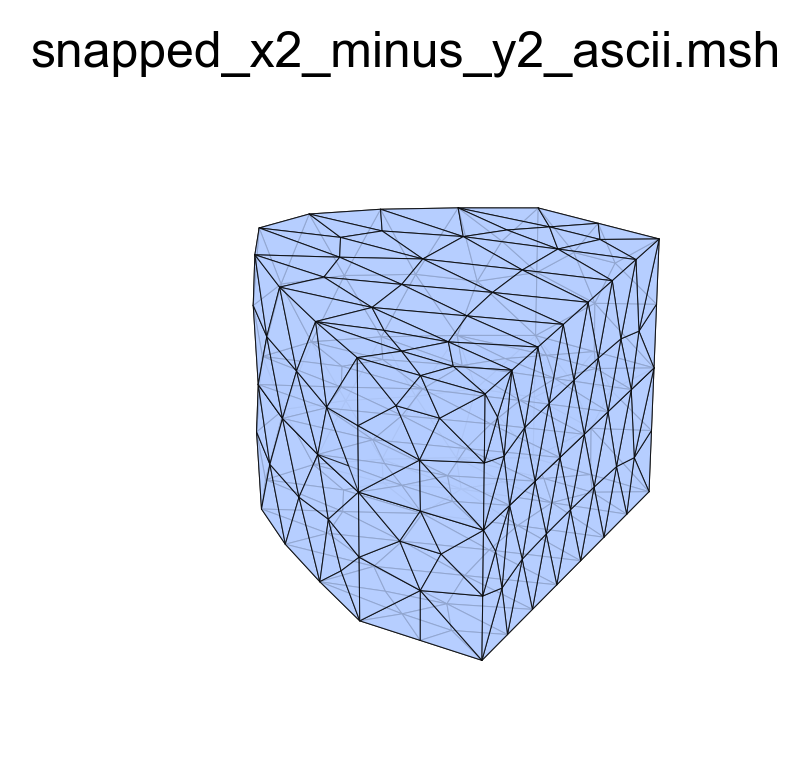

In [19]:
from pathlib import Path
from benchmarks._plot_mesh import show_mesh

mesh = Path(getattr(bench, "msh_path", "snapped_x2_minus_y2_ascii.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)


### 5.3 Canonicalize & Transform 


In [20]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (1.0000000000034803, -0.9999999999992149, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = 1.0000000000034803 -0.9999999999992149 0.0 0.0 0.0 0.0 0.0 0.0 0.0 -1.0
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (1.0000000000034803, -0.9999999999992149, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (1.0000000000034803, -0.9999999999992149, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(-1.0))
!!!!debug:before scaling (unscaled coeffs): (1.0000000000034803, -0.9999999999992149, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
a1 1.0000000000034803 b1 -0.9999999999992149 c1 0.0 d1 0.0 e1 0.0 f1 0.0  g1 0.0 h1 0.0 i1 0.0 j1 -1.0
sx 0.9999999999982598 a1 1.0000000000034803 g1 0.0 j1 -1.0 sy 1.0000000000003926 sz 1.0
A2 1.0 B2 -1.0 C2 0.0 D2 0.0 E2 0.0 F2 0.0  G2 0.0 H2 0.0 I2 0.0 J2 -1.0
A3 1.0 B3 -1.0 C3 0.0 

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0          154     0   120    15               1.0               1.0   
 1          155    29   120     0               1.0               1.0   
 2          156    15   120     3               1.0               1.0   
 3          157     3   120    38               1.0               1.0   
 4          158     5   122    23               1.0               1.0   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0                 1         2.236068         2.000000              0.0  ...   
 1                 1         1.843168         1.548311              0.0  ...   
 2                 1         2.236068         2.000000              0.5  ...   
 3                 1         2.236068         2.000000              1.0  ...   
 4                 1         2.236068        -2.000000              0.0  ...   
 
    ABC_A  ABC_B  ABC_C  ABC_D  ABC_E  ABC_F  ABC_G  ABC_H  ABC_I  ABC_J  
 0 

### 5.4 Curved Volume Estimation, Vertex-Wise Allocation, Aggregation and Error Analysis

In [21]:
import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

# --- V_flat: total/sum volume of the tet mesh
msh_path = "snapped_x2_minus_y2_ascii.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# --- V_theory = (z_max - z_min) * [ 2*x_max*Y - (Y*sqrt(1+Y^2) + asinh(Y)) ]
# given in your formula: (z_max - z_min)=2, x_max=3, Y=2
Y = 2.0
z_span = 2.0
x_max = 3.0
V_theory = z_span * (2.0 * x_max * Y - (Y * np.sqrt(1.0 + Y**2) + np.arcsinh(Y)))

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_flat=", V_flat)
print("V_sum =", V_sum)
print("V_theory=", V_theory)

rel = (V_flat + V_sum - V_theory) / V_theory * 100.0
print("**************************************************")
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6e}%")
print("**************************************************")


Saved: trn_Volume.csv
Sum of Vcorrection_scal = 0.063626312383
Sum of Vcorrection = 0.063626312383
Rows: 72, Elapsed: 0.37 s

V_flat= 12.104826866545324
V_sum = 0.06362631238337106
V_theory= 12.16845713964322
**************************************************
Volume CSV: c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_x2_minus_y2_ascii_COEFFS_Transformed_Volume.csv
relative error -3.254903e-05%
**************************************************


## 6. Ellipsoid
### 6.1 Load Ellipsoid Mesh & Fit Local Quadrics (ABC Coefficients)

In [22]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

bench = QuadricCoeffsFromMsh("Ellip_0_sub0_full.msh", method={})
bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(3), bench.coeffs_meta



[triangles] faces: 20
[mesh] points=12  surface_triangles=20
[RIM CHECK] vid 115 out of range (nV=12); skipping per-vertex print.
[smooth] components: 10 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\Ellip_0_sub0_full_POINT_TYPES.csv  (rim=12, planar=0, curved=0, surface_points=12, total_points=12)
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\Ellip_0_sub0_full_COEFFS.csv  (rows kept=20, skipped_flat=0, total_tris=20)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\Ellip_0_sub0_full_Tri_TYPE.csv  (triangles=20)
[write] rings -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\Ellip_0_sub0_full_RINGS.csv  (triangles=20)


(   triangle_id  component_id  component_size  A_id        Ax        Ay  \
 0            0             0               3     2 -0.788597 -0.850651   
 1            1             1               2     6  0.000000 -0.525731   
 2            2             2               2     4  0.000000 -0.525731   
 
          Az  B_id   Bx        By  ...       C_A  C_B     C_C  C_D  C_E  C_F  \
 0  0.000000     6  0.0 -0.525731  ...  0.444444  1.0  1.5625  0.0  0.0  0.0   
 1 -0.680521     7  0.0  0.525731  ...  0.444444  1.0  1.5625  0.0  0.0  0.0   
 2  0.680521     5  0.0  0.525731  ...  0.444444  1.0  1.5625  0.0  0.0  0.0   
 
    C_G  C_H  C_I  C_J  
 0  0.0  0.0  0.0 -1.0  
 1  0.0  0.0  0.0 -1.0  
 2  0.0  0.0  0.0 -1.0  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-master_BenchmarkCases\\Ellip_0_sub0_full_COEFFS.csv',
  'total_tris': 20,
  'skipped_flat': 0})

### 6.2 Ellipsoid Mesh Display

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\Ellip_0_sub0_full.msh

[loaded] Ellip_0_sub0_full.msh
  points: 12
  cells[tetra]: 18
  cells[triangle]: 20
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


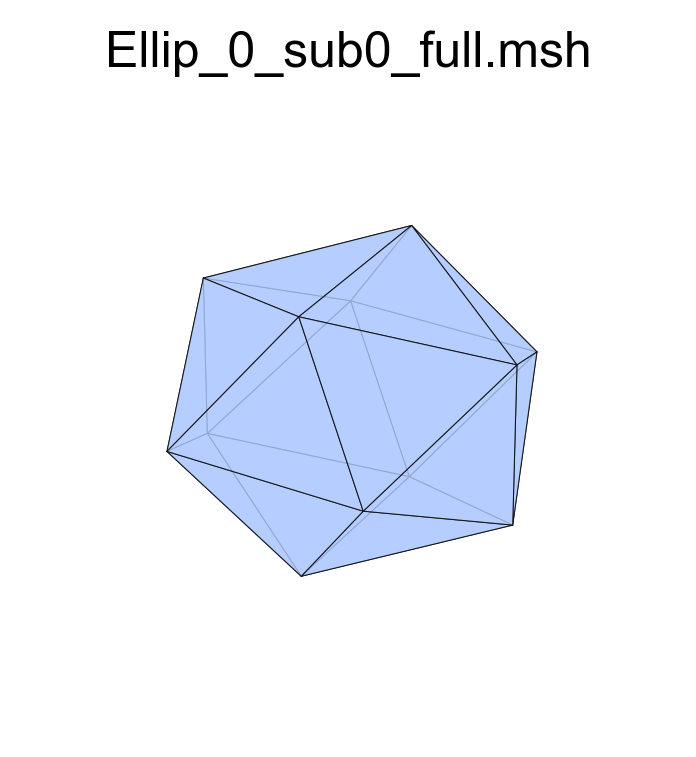

In [23]:
from pathlib import Path
from benchmarks._plot_mesh import show_mesh

mesh = Path(getattr(bench, "msh_path", "coarse_hyperboloid.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)


### 6.3 Canonicalize & Transform

In [24]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
print(out_tr_csv)       
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (0.4444444444444439, 1.0, 1.5624999999999991, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = 0.4444444444444439 1.0 1.5624999999999991 0.0 0.0 0.0 0.0 0.0 0.0 -1.0
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (0.4444444444444439, 1.0, 1.5624999999999991, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (0.4444444444444439, 1.0, 1.5624999999999991, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(-1.0))
!!!!debug:before scaling (unscaled coeffs): (0.4444444444444439, 1.0, 1.5624999999999991, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0)
a1 0.4444444444444439 b1 1.0 c1 1.5624999999999991 d1 0.0 e1 0.0 f1 0.0  g1 0.0 h1 0.0 i1 0.0 j1 -1.0
sx 1.5000000000000009 a1 0.4444444444444439 g1 0.0 j1 -1.0 sy 1.0 sz 0.8000000000000003
A2 1.0 B2 1.0 C2 1.0000000000000002 D2 0.0 E2 0.0 F2 0.0  G2 0.0 H2 0.0 I2 0.0 J2 -1.0
A3 1.0 B3 1.0 

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0            0     2     6    10               1.5                 1   
 1            1     6     7    10               1.5                 1   
 2            2     4     5     9               1.5                 1   
 3            3     1     5     9               1.5                 1   
 4            4     2     4    11               1.5                 1   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0               0.8        -0.525731        -0.850651         0.000000  ...   
 1               0.8         0.000000        -0.525731        -0.850651  ...   
 2               0.8         0.000000        -0.525731         0.850651  ...   
 3               0.8         0.525731         0.850651         0.000000  ...   
 4               0.8        -0.525731        -0.850651         0.000000  ...   
 
       ABC_A  ABC_B   ABC_C  ABC_D  ABC_E  ABC_F  ABC_G  ABC_H  ABC_I  ABC_J  

### 6.4 Curved Volume Estimation, Vertex-Wise Allocation, Aggregation and Error Analysis

In [25]:


import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

import numpy as np, pandas as pd
# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)
V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))

# --- V_flat: total/sum volume of the tet mesh
msh_path = "Ellip_0_sub0_full.msh"
V_flat = total_tet_volume_from_msh(msh_path)

ax, ay, az = 1.5, 1.0, 0.8
V_theory = (4.0 / 3.0) * np.pi * ax * ay * az

rel = (V_theory - V_flat - V_sum) / V_theory * 100.0
print("**************************************************")
print("V_flat =", V_flat)
print("V_sum  =", V_sum)
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.16}%")
print("**************************************************")


[tri 0] ||A||=1.000000000 ||B||=1.000000000 ||C||=1.000000000 | det(ellip)=1.200000000
           Omega=0.628318530718  Vw=0.209439510239  Vf=0.126807535506
           Vcor_sphere=0.082631974733  sum(parts_sphere)=0.082631974733
           Vcor_ellip =0.099158369680  sum(parts_ellip) =0.099158369680  side=outside
           A_curved=0.751249634940  A_flat=0.575136997370  A_split=(0.250416544980,0.250416544980,0.250416544980)
           a=(-0.525731112119,-0.850650808352,0.000000000000)  b=(0.000000000000,-0.525731112119,-0.850650808352)  c=(-0.850650808352,0.000000000000,-0.525731112119)
[tri 1] ||A||=1.000000000 ||B||=1.000000000 ||C||=1.000000000 | det(ellip)=1.200000000
           Omega=0.628318530718  Vw=0.209439510239  Vf=0.126807535506
           Vcor_sphere=0.082631974733  sum(parts_sphere)=0.082631974733
           Vcor_ellip =0.099158369680  sum(parts_ellip) =0.099158369680  side=outside
           A_curved=0.872351268816  A_flat=0.684598384691  A_split=(0.290783756272,0.29078

In [26]:
# ---------- Ellipsoid surface area: theory vs CSV sum ----------
def _ellipsoid_area_quadrature(ax: float, ay: float, az: float,
                               n_theta: int = 256, n_phi: int = 512) -> float:
    """
    Compute exact ellipsoid surface area numerically via sphere->ellipsoid map:
      A = abc * ∫_S ||T^{-T} s|| dΩ
    with s on the unit sphere parameterized by (theta, phi).
    Uses Gauss-Legendre in mu = cos(theta) and trapezoidal in phi.
    """
    a, b, c = float(ax), float(ay), float(az)
    abc = a * b * c

    # Gauss-Legendre in mu ∈ [-1,1]
    mu, w_mu = np.polynomial.legendre.leggauss(n_theta)  # mu = cos(theta)
    # Uniform trapezoid in phi ∈ [0, 2π)
    phi = np.linspace(0.0, 2.0 * np.pi, num=n_phi, endpoint=False)
    dphi = (2.0 * np.pi) / n_phi

    # Precompute 1/a^2 etc.
    ia2, ib2, ic2 = (1.0 / (a * a), 1.0 / (b * b), 1.0 / (c * c))

    # Integrand: ||T^{-T} s|| where s = (sqrt(1-mu^2)cosφ, sqrt(1-mu^2)sinφ, mu)
    # dΩ = dphi * dmu (since we changed variable to mu = cosθ)
    one_minus_mu2 = 1.0 - mu**2  # shape (n_theta,)
    sqrt_one_minus_mu2 = np.sqrt(np.clip(one_minus_mu2, 0.0, 1.0))

    cos_phi = np.cos(phi)[None, :]   # (1, n_phi)
    sin_phi = np.sin(phi)[None, :]   # (1, n_phi)

    sx = sqrt_one_minus_mu2[:, None] * cos_phi  # (n_theta, n_phi)
    sy = sqrt_one_minus_mu2[:, None] * sin_phi
    sz = mu[:, None]  # broadcast

    integrand = np.sqrt(ia2 * sx * sx + ib2 * sy * sy + ic2 * sz * sz)  # (n_theta, n_phi)

    # Integrate over phi (trapezoid) then over mu (Gauss-Legendre)
    integ_phi = np.sum(integrand, axis=1) * dphi          # (n_theta,)
    area = abc * np.sum(integ_phi * w_mu)                 # scalar
    return float(area)

# Sum A_curved from CSV (0 if column missing)
A_sum = float(np.nansum(vdf.get("A_curved", 0.0)))

# Theoretical ellipsoid surface area (adjust resolution if needed)
A_theory = _ellipsoid_area_quadrature(ax, ay, az, n_theta=256, n_phi=512)

relA = (A_theory - A_sum) / A_theory * 100.0

print("**************** AREA CHECK *********************")
print(f"A_sum (from CSV):         {A_sum:.12f}")
print(f"A_theory (quadrature):    {A_theory:.12f}")
print(f"relative area error:      {relA:.16e}%")
print("*************************************************")


**************** AREA CHECK *********************
A_sum (from CSV):         14.931227000752
A_theory (quadrature):    14.930856544871
relative area error:      -2.4811428561708967e-03%
*************************************************


In [27]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh
 
bench = QuadricCoeffsFromMsh("snapped_y_eq_x2_ascii_transf.msh", method={})
bench.run_coeffs_stage(min_pts=10, theta_max_deg=55.0)
bench.coeffs_df.head(3), bench.coeffs_meta


[triangles] faces: 266
[mesh] points=135  surface_triangles=266
[RIM CHECK] theta_max_deg=55.0  dihedral(115)=54.004896  rim_flags[115]=False
[smooth] components: 5 (theta_max=55.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_transf_POINT_TYPES.csv  (rim=34, planar=6, curved=88, surface_points=128, total_points=135)

[DEBUG T208] verts: A=39 B=115 C=40  rim-depths=(1000000000, 1000000000, 1000000000)
[DEBUG T208] |A|=13  |B|=18  |C|=13  |ABC|=20
[DEBUG T208] ABC IDs: [4, 6, 38, 39, 40, 41, 104, 105, 106, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 121]
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_transf_COEFFS.csv  (rows kept=104, skipped_flat=162, total_tris=266)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_transf_Tr

(   triangle_id  component_id  component_size  A_id        Ax        Ay  \
 0           52             1             104     0 -3.331951  2.000000   
 1           53             1             104    22 -3.282249  0.987435   
 2           54             1             104    10 -1.883062  2.000000   
 
          Az  B_id        Bx        By  ...       C_A  C_B       C_C  C_D  C_E  \
 0 -0.892794    70 -2.955336  1.340854  ... -0.066987  0.0 -0.933013  0.0  0.5   
 1 -1.078286    70 -2.955336  1.340854  ... -0.066987  0.0 -0.933013  0.0  0.5   
 2 -0.504565    66 -1.702821  1.318688  ... -0.066987  0.0 -0.933013  0.0  0.5   
 
    C_F       C_G  C_H       C_I  C_J  
 0  0.0  0.732051  0.5 -2.732051 -1.0  
 1  0.0  0.732051  0.5 -2.732051 -1.0  
 2  0.0  0.732051  0.5 -2.732051 -1.0  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-master_BenchmarkCases\\snapped_y_eq_x2_ascii_transf_COEFFS.csv',
  'total_tris': 266,
  'skipped_flat': 

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\snapped_y_eq_x2_ascii_transf.msh

[loaded] snapped_y_eq_x2_ascii_transf.msh
  points: 135
  cells[triangle]: 266
  cells[tetra]: 420
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


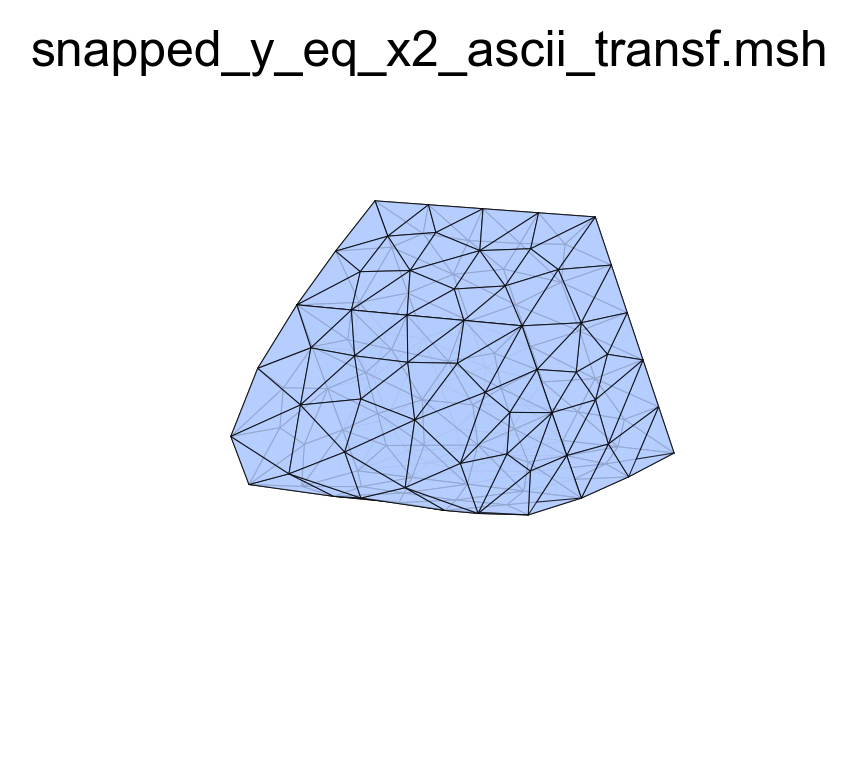

In [28]:
from pathlib import Path
from benchmarks._plot_mesh import show_mesh

mesh = Path(getattr(bench, "msh_path", "snapped_y_eq_x2_ascii_transf.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)


In [29]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (-0.0669872981075884, 0.0, -0.9330127018895934, 0.0, 0.4999999999985815, 0.0, 0.7320508075685774, 0.4999999999997089, -2.732050807567764, -1.0)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = -0.0669872981075884 0.0 -0.9330127018895934 0.0 0.4999999999985815 0.0 0.7320508075685774 0.4999999999997089 -2.732050807567764 -1.0
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (np.float64(-0.9999999999971827), np.float64(6.042709959046326e-43), np.float64(6.85117694031953e-16), 0.0, 0.0, 0.0, np.float64(-2.828427124745037), np.float64(0.4999999999997089), np.float64(3.061616998732655e-17), -1.0)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[-2.58819045e-01  2.86809890e-14  9.65925826e-01]
 [ 0.00000000e+00  1.00000000e+00 -2.96927447e-14]
 [ 9.65925826e-01  7.68504783e-15  2.58819045e-01]]
#### shifted along pure-linear axis 1 by -2.000000000009172 to set J=0
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (-0.9999999999971827, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4999

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0           52     0    70     8               1.0               2.0   
 1           53    22    70     0               1.0               2.0   
 2           54    10    66     1               1.0               2.0   
 3           55     1    66    23               1.0               2.0   
 4           56     4    67    22               1.0               2.0   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0                 1         1.414214         2.000000         -3.44949  ...   
 1                 1         1.222177         1.493717         -3.44949  ...   
 2                 1         1.414214         2.000000         -1.94949  ...   
 3                 1         1.414214         2.000000         -1.44949  ...   
 4                 1         1.000000         1.000000         -3.44949  ...   
 
       ABC_A  ABC_B     ABC_C  ABC_D  ABC_E  ABC_F     ABC_G  ABC_H     ABC_I 

In [30]:
import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_sum =", V_sum)

# --- V_flat: total/sum volume of the tet mesh
msh_path = "snapped_y_eq_x2_ascii_transf.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# --- V_theory = (z_max - z_min) * (4/3) * y_max^(3/2) * 2
# Use your known constants for this transformed case:
# (z_max - z_min) ≈ 5.65685425, y_max = 1.0  -> matches your previous numbers, then *2
z_span = 5.65685425
y_max = 1.0
V_theory = z_span * (4.0 / 3.0) * (y_max ** 1.5) * 2.0

rel = (V_theory - V_flat - V_sum * 2.0) / V_theory * 100.0
print("**************************************************")
print("V_theory =", V_theory)
print("V_flat   =", V_flat)
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6e}%")
print("**************************************************")

Debug info for patch idx: 239
A_in: [ 0.5204381   0.27085582 -1.9230571 ] B_in: [ 0.60113743  0.36136621 -2.44216964] C_in: [ 0.26560637  0.07054675 -2.43310348]
A_top: [ 0.5204381   0.27085582 -1.9230571 ] C_top: [ 0.26560637  0.07054675 -1.9230571 ] D_top: [ 0.599783    0.35973965 -1.9230571 ]
A_middle: [ 0.5204381   0.27085582 -2.43310348] C_middle: [ 0.26560637  0.07054675 -2.43310348] D_middle: [ 0.599783    0.35973965 -2.43310348]
B_bottom: [ 0.60113743  0.36136621 -2.44216964] C_bottom: [ 0.26560637  0.07054675 -2.44216964] D_bottom: [ 0.599783    0.35973965 -2.44216964]
V_patch1=0.001299000095129082, V_patch2=2.830964312270327e-05, V_ABCD=-2.7000231907201165e-06
coeffs: (-1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)
Saved: trn_Volume.csv
Sum of Vcorrection_scal = 0.185656970509
Sum of Vcorrection = 0.092828485255
Rows: 104, Elapsed: 0.12 s
V_sum = 0.09282848525461436

**************************************************
V_theory = 15.084944666666667
V_flat   = 14.89927340470

## Transformed Hyperboloid

In [31]:
from benchmarks._benchmark_cases import QuadricCoeffsFromMsh

bench = QuadricCoeffsFromMsh("coarse_hyperboloid_transf.msh", method={})
bench.run_coeffs_stage(min_pts=10, theta_max_deg=35.0)
bench.coeffs_df.head(3), bench.coeffs_meta


[triangles] faces: 238
[mesh] points=129  surface_triangles=238
[RIM CHECK] theta_max_deg=35.0  dihedral(115)=0.000001  rim_flags[115]=False
[smooth] components: 4 (theta_max=35.0°)
[write] point types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_transf_POINT_TYPES.csv  (rim=44, planar=14, curved=63, surface_points=121, total_points=129)

[DEBUG T208] verts: A=32 B=103 C=31  rim-depths=(1000000000, 1000000000, 1000000000)
[DEBUG T208] |A|=11  |B|=14  |C|=11  |ABC|=11
[DEBUG T208] ABC IDs: [1, 19, 29, 30, 31, 32, 99, 101, 103, 115, 116]
[write] CSV -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_transf_COEFFS.csv  (rows kept=124, skipped_flat=114, total_tris=238)
[ok] Non-planar ABC rows written.
[write] tri types -> c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_transf_Tri_TYPE.csv  (triangles=238)
[write] rings -> c:\Users\

(   triangle_id  component_id  component_size  A_id        Ax        Ay  \
 0           57             1             123     0  2.292893  1.000000   
 1           58             1             123    18  2.119984  0.424788   
 2           59             1             123     4  2.974338  1.000000   
 
          Az  B_id        Bx        By  ...       C_A       C_B       C_C  C_D  \
 0 -1.707107     5  2.119984  1.575212  ... -0.187497  0.500022 -0.187514  0.0   
 1 -1.534198     0  2.292893  1.000000  ... -0.187497  0.500022 -0.187514  0.0   
 2 -0.225828    19  3.534198  1.575212  ... -0.187497  0.499975 -0.187485  0.0   
 
         C_E  C_F       C_G       C_H       C_I  C_J  
 0 -0.625035  0.0  0.999997 -1.000042  1.000047 -1.0  
 1 -0.625035  0.0  0.999997 -1.000042  1.000047 -1.0  
 2 -0.624972  0.0  0.999987 -0.999962  0.999953 -1.0  
 
 [3 rows x 61 columns],
 {'out_csv': 'c:\\Users\\s.deng\\Downloads\\Rerun_cases\\8Geometries\\ddgclib-master_BenchmarkCases\\coarse_hyperboloid_tr

Plotting mesh: C:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_transf.msh

[loaded] coarse_hyperboloid_transf.msh
  points: 129
  cells[triangle]: 238
  cells[tetra]: 355
[info] PyVista unavailable or failed (No module named 'pyvista'). Using Matplotlib fallback.


c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\benchmarks\_plot_mesh.py:115: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


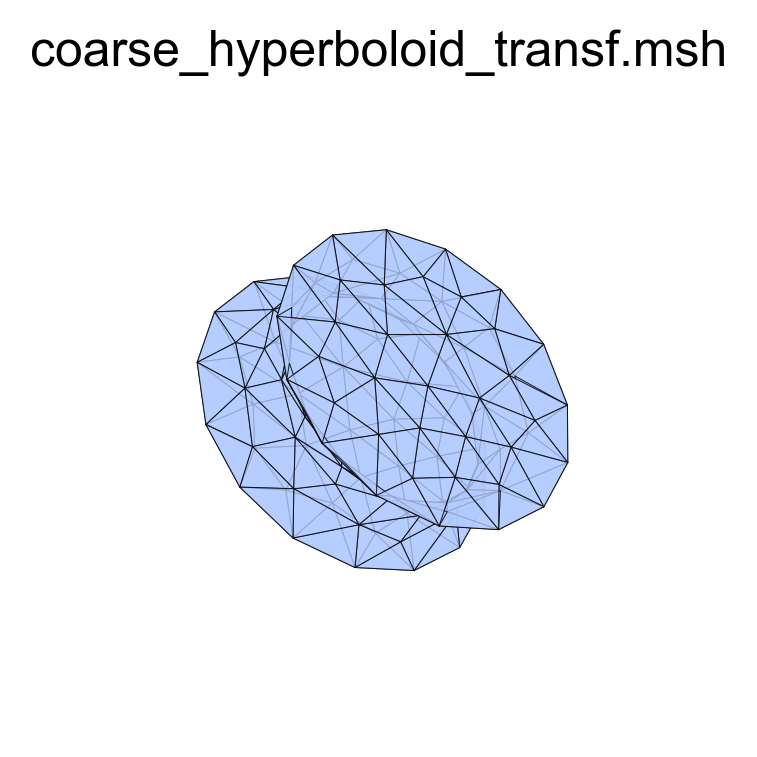

In [32]:
from pathlib import Path
from benchmarks._plot_mesh import show_mesh

mesh = Path(getattr(bench, "msh_path", "parabolic_cylinder_y_eq_x2_y1slice_transf.msh")).resolve()
print("Plotting mesh:", mesh)
show_mesh(mesh)

In [33]:
out_tr_csv = bench.run_transform_stage()  # uses the Part-1 CSV by default
bench.coeffs_tr_df.head(), bench.coeffs_tr_meta

!!!!debug:input coeffs (raw): (-0.1874986526824846, 0.5000121750610775, -0.1875096285832661, 0.0, -0.6250187897604167, 0.0, 0.999997008761545, -1.0000281845787646, 1.0000201081547502, -1.0)
A0,B0,C0,D0,E0,F0,G0,H0,I0,J0 = -0.1874986526824846 0.5000121750610775 -0.1875096285832661 0.0 -0.6250187897604167 0.0 0.999997008761545 -1.0000281845787646 1.0000201081547502 -1.0
!!!!debug:after quadric_major_z_minor_x coeffs_rot: (np.float64(0.5000121750610775), np.float64(0.12500525429551967), np.float64(-0.5000135355612704), 0.0, 0.0, 0.0, np.float64(1.0000281845787644), np.float64(-3.916190420838461e-06), np.float64(1.414225665949582), -1.0)
!!!!debug:after quadric_major_z_minor_x Rotation:
 [[ 4.62586403e-17  7.07112990e-01  7.07100572e-01]
 [-1.00000000e+00  1.11022302e-16  0.00000000e+00]
 [-1.11022302e-16 -7.07100572e-01  7.07112990e-01]]
!!!!debug:before _clean_coeffs new_coeffs_unscaled: (0.5000121750610775, 0.12500525429551967, -0.5000135355612704, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float

(   triangle_id  A_id  B_id  C_id  scale_factors1_x  scale_factors1_y  \
 0           57     0     5     2          1.000014          2.000010   
 1           58    18     0     2          1.000005          1.999981   
 2           59     4    19     1          1.000009          1.999998   
 3           60    32     4     1          1.000015          2.000009   
 4           61     3    62     2          1.000012          1.999978   
 
    scale_factors1_z  A_transformed_x  A_transformed_y  A_transformed_z  ...  \
 0          1.000012         0.000004         1.414208        -0.999986  ...   
 1          1.000003        -0.575202        -1.291963        -0.999998  ...   
 2          1.000007         0.000002         1.131421        -0.529265  ...   
 3          1.000012        -0.575204         1.291931        -0.999986  ...   
 4          1.000008        -0.000011         1.000013         0.000005  ...   
 
       ABC_A     ABC_B     ABC_C     ABC_D     ABC_E  ABC_F     ABC_G  \
 0 -0

In [34]:
import numpy as np, pandas as pd
import meshio

def tet_volumes(points, tets):
    t = tets[:, :4].astype(int)
    a = points[t[:, 0]]
    b = points[t[:, 1]]
    c = points[t[:, 2]]
    d = points[t[:, 3]]
    return np.abs(np.einsum("ij,ij->i", np.cross(b - a, c - a), d - a)) / 6.0

def total_tet_volume_from_msh(msh_path: str) -> float:
    mesh = meshio.read(msh_path)
    pts = mesh.points[:, :3]
    V = 0.0
    for cb in mesh.cells:
        if cb.type in ("tetra", "tetra10", "tetra20", "tetra35"):
            V += float(np.sum(tet_volumes(pts, cb.data)))
    return V

import numpy as np, pandas as pd
# Stage 3 (works regardless of CWD if you applied the _find_script fix)
bench.run_volume_stage(tr_csv=bench.coeffs_tr_meta["out_csv"])

vol_csv = bench.vol_meta["vol_csv"]
vdf = bench.vol_df if (getattr(bench, "vol_df", None) is not None and "Vcorrection" in bench.vol_df) \
     else pd.read_csv(vol_csv)

V_sum = float(np.nansum(vdf.get("Vcorrection", 0.0)))
print("V_sum =", V_sum)

# --- V_flat: total/sum volume of the tet mesh
msh_path = "coarse_hyperboloid_transf.msh"
V_flat = total_tet_volume_from_msh(msh_path)

# --- V_new = 2 * V_orig = 2 * (8/3)π = (16/3)π
V_new = (16.0 / 3.0) * np.pi

rel = (V_new - V_flat - V_sum * 1.0) / V_new * 100.0
print("**************************************************")
print("V_new  =", V_new)
print("V_flat =", V_flat)
print(f"Volume CSV: {vol_csv}\nrelative error {rel:.6f}%")
print("**************************************************")

c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\ddgclib\../benchmarks\_3_4_shared_axisymmetric_utils.py:1106: RuntimeWarning: invalid value encountered in sqrt
  s = 1.0 / np.sqrt(denom)


[input] C:\Users\S272D~1.DEN\AppData\Local\Temp\tmpg_qe5et3\rot.csv
Triangles kept (curved): 124 | planar skipped: 0
Patch-based total (sum of patches): 0.15319201
Total elapsed: 0.99 s
[write] C:\Users\S272D~1.DEN\AppData\Local\Temp\tmpg_qe5et3\rot_Volume.csv
V_sum = 0.1531920115762072

**************************************************
V_new  = 16.755160819145562
V_flat = 16.60295583495276
Volume CSV: c:\Users\s.deng\Downloads\Rerun_cases\8Geometries\ddgclib-master_BenchmarkCases\coarse_hyperboloid_transf_COEFFS_Transformed_Volume.csv
relative error -0.005891%
**************************************************


In [35]:
import sys
import numpy as np
import scipy

print("Python:", sys.version)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)

Python: 3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]
numpy: 2.1.3
scipy: 1.17.1
